<a href="https://colab.research.google.com/github/hieutran121197/python-data-science-final/blob/main/Final_Assignment_Stock_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
!pip install yfinance beautifulsoup4 matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Define the `make_graph` function

In [ ]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data.copy()
    dates = pd.to_datetime(stock_data_specific["Date"])
    if dates.dt.tz is not None:
        dates = dates.dt.tz_localize(None)
    stock_data_specific["Date"] = dates
    stock_data_specific = stock_data_specific[stock_data_specific["Date"] <= "2021-06-14"]

    revenue_data_specific = revenue_data.copy()
    revenue_data_specific["Date"] = pd.to_datetime(revenue_data_specific["Date"])
    revenue_data_specific = revenue_data_specific[revenue_data_specific["Date"] <= "2021-04-30"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(stock_data_specific["Date"], stock_data_specific["Close"].astype(float), color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    axes[1].plot(revenue_data_specific["Date"], revenue_data_specific["Revenue"].astype(float), color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Question 1: Use yfinance to Extract Tesla Stock Data

In [ ]:
tesla = yf.Ticker("TSLA")

In [ ]:
tesla_data = tesla.history(period="max")

In [ ]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Use Webscraping to Extract Tesla Revenue Data

In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text

In [ ]:
soup = BeautifulSoup(html_data, "html.parser")

In [ ]:
rows = []
for table in soup.find_all("table"):
    if "Tesla Quarterly Revenue" in table.get_text():
        for row in table.find("tbody").find_all("tr"):
            col = row.find_all("td")
            if len(col) == 2:
                rows.append({"Date": col[0].text.strip(), "Revenue": col[1].text.strip()})
        break

tesla_revenue = pd.DataFrame(rows, columns=["Date", "Revenue"])

In [ ]:
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(r",|\$", "", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

In [ ]:
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## Question 3: Use yfinance to Extract GameStop Stock Data

In [ ]:
gme = yf.Ticker("GME")

In [ ]:
gme_data = gme.history(period="max")

In [ ]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: Use Webscraping to Extract GameStop Revenue Data

In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url).text

In [ ]:
soup = BeautifulSoup(html_data_2, "html.parser")

In [ ]:
rows = []
for table in soup.find_all("table"):
    if "GameStop Quarterly Revenue" in table.get_text():
        for row in table.find("tbody").find_all("tr"):
            col = row.find_all("td")
            if len(col) == 2:
                rows.append({"Date": col[0].text.strip(), "Revenue": col[1].text.strip()})
        break

gme_revenue = pd.DataFrame(rows, columns=["Date", "Revenue"])
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(r",|\$", "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

In [ ]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Question 5: Plot Tesla Stock Graph

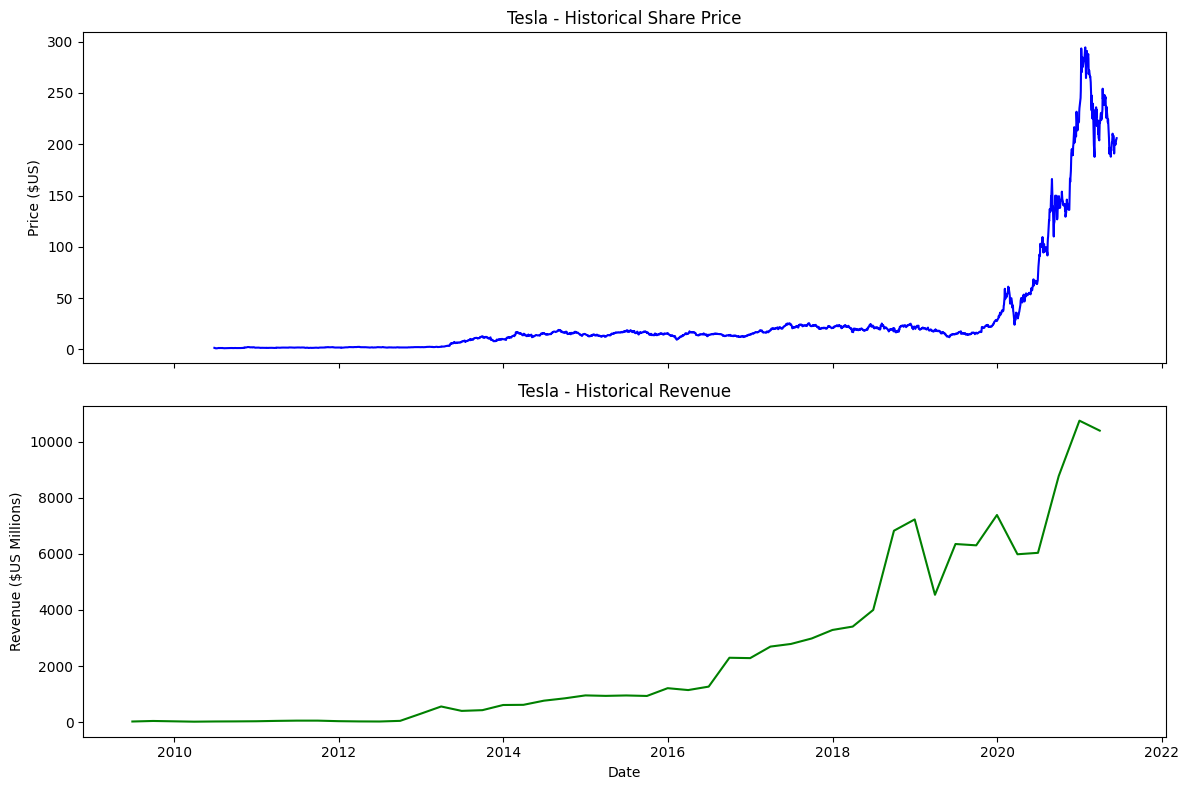

In [ ]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

## Question 6: Plot GameStop Stock Graph

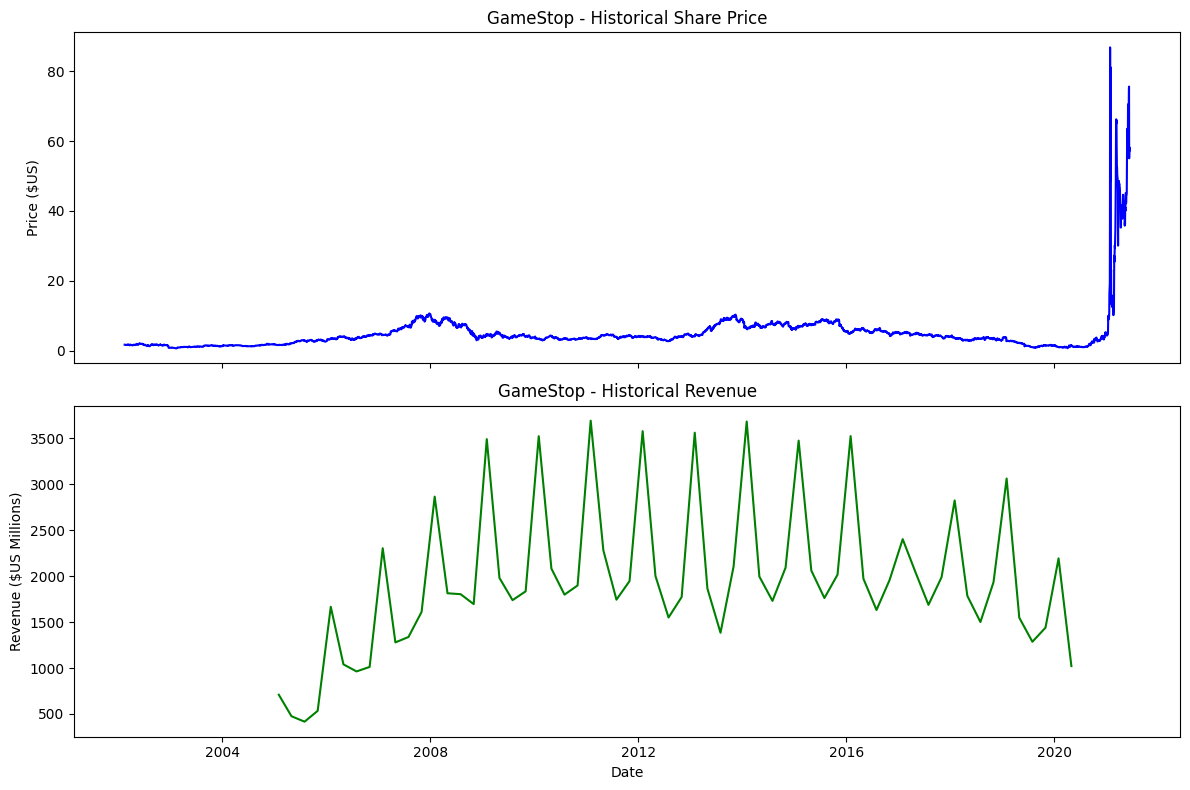

In [ ]:
make_graph(gme_data, gme_revenue, 'GameStop')